In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

URL = Path("../data/raw/california_housing.csv")

def load_housing_data(URL):
    return pd.read_csv(URL)

housing_data = load_housing_data(URL)

housing_data.head(10)
housing_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Splitting the data into training set and testing set

In [2]:
X = housing_data.drop("median_house_value",axis=1)
y = housing_data["median_house_value"]

In [ ]:
housing_data['rooms_per_house'] = housing_data['total_rooms'] / housing_data['households']
housing_data['bedrooms_per_house'] = housing_data['total_bedrooms'] / housing_data['households']
housing_data['people_per_house'] = housing_data['total_rooms'] / housing_data['households']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

14196    103000.0
8267     382100.0
17445    172600.0
14265     93400.0
2271      96500.0
           ...   
11284    229200.0
11964     97800.0
5390     222100.0
860      283500.0
15795    325000.0
Name: median_house_value, Length: 16512, dtype: float64


## Getting insights from the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
 10  rooms_per_house     20640 non-null  float64
 11  bedrooms_per_house  20433 non-null  float64
 12  people_per_house    20640 non-null  float64
dtypes: float64(12), object(1)
memory usage: 2.0+ MB
       total_bedrooms
0               129.0
1              1106.0
2               190.0
3              

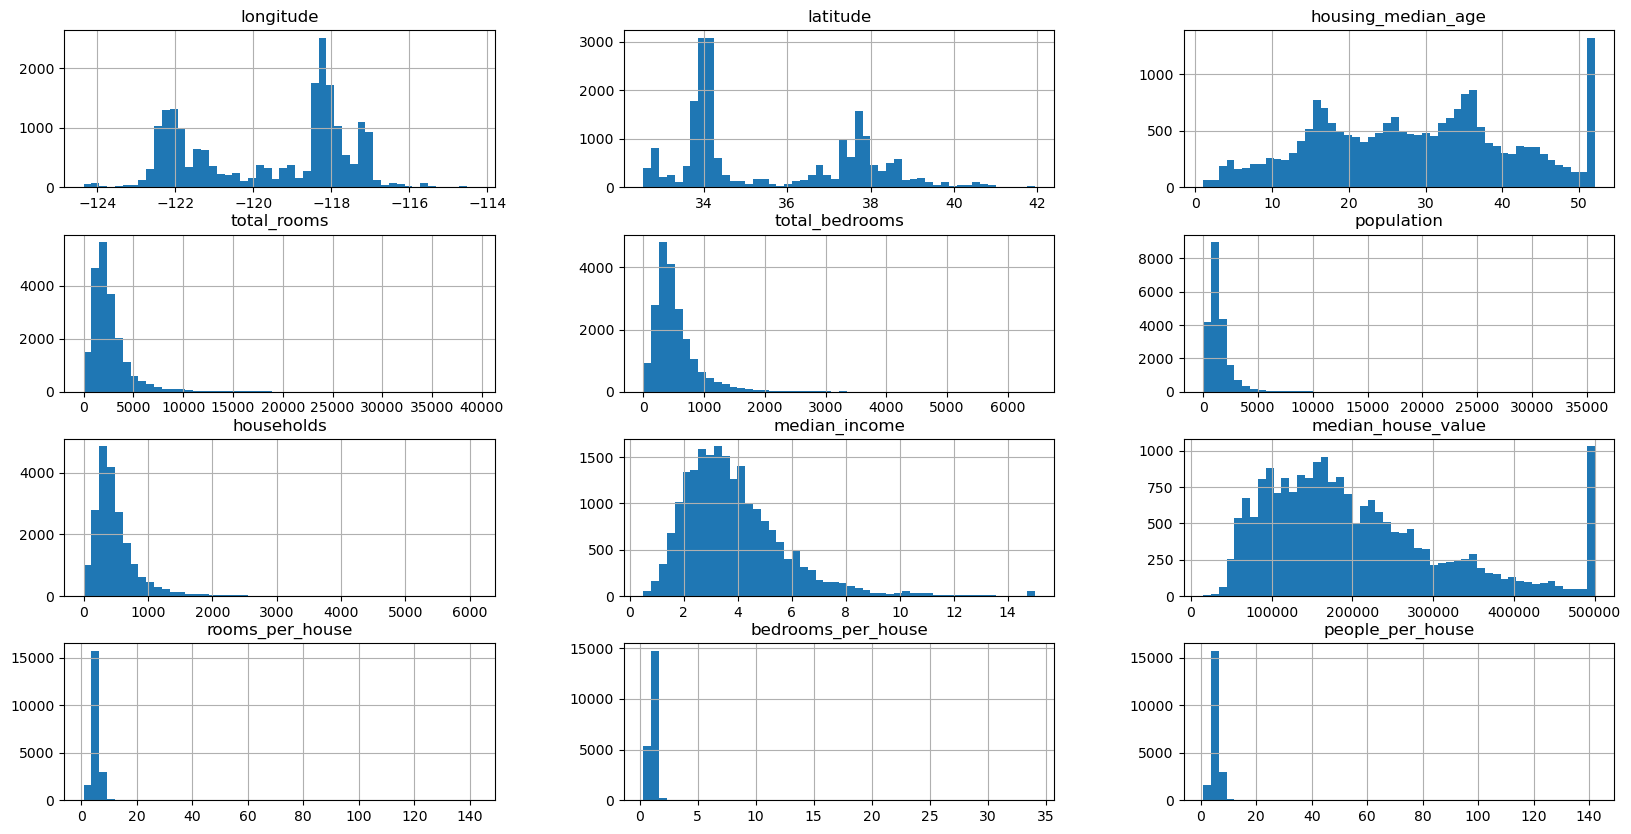

In [4]:
housing_data.head()
housing_data.info()
housing_data.describe()
housing_data.hist(bins=50,figsize=(20,10))
print(housing_data[["total_bedrooms"]])

## Correlation Analysis

In [5]:
# corr_matrix = housing_data.corr()
housing_data.info()
housing_data_eda = housing_data.copy()
housing_data_eda = pd.get_dummies(housing_data,columns=['ocean_proximity'])

housing_data_eda["bedrooms_per_house"] = housing_data_eda["total_bedrooms"] / housing_data_eda["households"]
housing_data_eda["rooms_per_house"] = housing_data_eda["total_rooms"] / housing_data_eda["households"]
housing_data_eda["people_per_house"] = housing_data_eda["population"] / housing_data_eda["households"]


corr_matrix = housing_data_eda.corr()
# corr_matrix.info()
corr_matrix["median_house_value"].sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
 10  rooms_per_house     20640 non-null  float64
 11  bedrooms_per_house  20433 non-null  float64
 12  people_per_house    20640 non-null  float64
dtypes: float64(12), object(1)
memory usage: 2.0+ MB


median_house_value            1.000000
median_income                 0.688075
ocean_proximity_<1H OCEAN     0.256617
ocean_proximity_NEAR BAY      0.160284
rooms_per_house               0.151948
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049686
ocean_proximity_ISLAND        0.023416
people_per_house             -0.023737
population                   -0.024650
longitude                    -0.045967
bedrooms_per_house           -0.046739
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64

In [6]:

from sklearn.base import BaseEstimator, TransformerMixin
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self # nothing else to do
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
            bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)



## Creating machine learning pipeline

In [24]:

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
housing_data_num = housing_data.drop("ocean_proximity", axis=1)
num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy="median")),
('attribs_adder', CombinedAttributesAdder()),
('std_scaler', StandardScaler()),
])



In [30]:
from sklearn.compose import ColumnTransformer
num_attribs = list(X_train.drop("ocean_proximity",axis=1))
cat_attribs = ["ocean_proximity"]
print(cat_attribs)
full_pipeline = ColumnTransformer([
("num", num_pipeline, num_attribs),
("cat", OneHotEncoder(), cat_attribs),
])
housing_prepared = full_pipeline.fit_transform(X_train)
print((housing_prepared[0]))

['ocean_proximity']
[ 1.27258656 -1.3728112   0.34849025  0.22256942  0.21122752  0.76827628
  0.32290591 -0.326196   -0.17491646  0.05137609 -0.2117846   0.
  0.          0.          0.          1.        ]


In [31]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(housing_prepared,y_train)

LinearRegression()

## Model Evaluation

In [35]:
some_data = X_train.iloc[:5]
some_labels = y_train.iloc[:5]

some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:" , lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predictions: [181746.54359616 290558.74973505 244957.50017771 146498.51061398
 163230.42393939]
Labels: [103000.0, 382100.0, 172600.0, 93400.0, 96500.0]


In [ ]:
from sklearn.metrics import mean_squared_error #Cost function
import numpy as np

train_preds = lin_reg.predict(full_pipeline.transform(X_train))
rmse = np.sqrt(mean_squared_error(y_train, train_preds))
rmse

np.float64(67593.20745775253)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, y_train)

In [ ]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(y_train, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse
